In [1]:
#Website Traffic Analysis
#Import Libraries
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Upload Dataset
from google.colab import files
uploaded = files.upload()
#Load Dataset
df = pd.read_csv('traffic.csv')   # make sure filename matches upload
df.head()

Saving traffic.csv to traffic.csv


,event,date,country,city,artist,album,track,isrc,linkid
0,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
1,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
2,click,2021-08-21,India,Ludhiana,Reyanna Maria,So Pretty,So Pretty,USUM72100871,23199824-9cf5-4b98-942a-34965c3b0cc2
3,click,2021-08-21,France,Unknown,"Simone & Simaria, Sebastian Yatra",No Llores Más,No Llores Más,BRUM72003904,35573248-4e49-47c7-af80-08a960fa74cd
4,click,2021-08-21,Maldives,Malé,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8


In [9]:
import pandas as pd

# Basic Info
print("Shape:", df.shape)
print("\nInfo:")
df.info()
print("\nMissing Values:")
print(df.isnull().sum())

# Standardize column names
df.columns = df.columns.str.strip().str.lower()

# Convert 'date' column to datetime objects first
df['date'] = pd.to_datetime(df['date'])

# Rename 'linkid' to 'user_id' and 'date' to 'timestamp'
df = df.rename(columns={'linkid': 'user_id', 'date': 'timestamp'})

# Drop rows where critical values are missing (now using corrected names)
df = df.dropna(subset=['user_id', 'timestamp'])

# Sort data
df = df.sort_values(by=['user_id', 'timestamp'])

# Remove duplicates
df = df.drop_duplicates()

# Final preview
df.head()

Shape: (226278, 9)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226278 entries, 0 to 226277
Data columns (total 9 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   event    226278 non-null  object
 1   date     226278 non-null  object
 2   country  226267 non-null  object
 3   city     226267 non-null  object
 4   artist   226241 non-null  object
 5   album    226273 non-null  object
 6   track    226273 non-null  object
 7   isrc     219157 non-null  object
 8   linkid   226278 non-null  object
dtypes: object(9)
memory usage: 15.5+ MB

Missing Values:
event         0
date          0
country      11
city         11
artist       37
album         5
track         5
isrc       7121
linkid        0
dtype: int64


,event,timestamp,country,city,artist,album,track,isrc,user_id
199012,pageview,2021-08-19,United States,Wetumpka,Gunna,Drip Season 3 (Deluxe),Spending Addiction,NaN,00073307-ae96-5089-a117-4783afb42f8e
154114,pageview,2021-08-20,United States,Queens,Gunna,Drip Season 3 (Deluxe),Spending Addiction,NaN,00073307-ae96-5089-a117-4783afb42f8e
1248,click,2021-08-19,United States,Valrico,Jhené Aiko,Chilombo,P*$$Y Fairy (OTW),NaN,00126b32-0c35-507b-981c-02c80d2aa8e7
21084,click,2021-08-19,United States,San Antonio,Jhené Aiko,Chilombo,P*$$Y Fairy (OTW),NaN,00126b32-0c35-507b-981c-02c80d2aa8e7
152893,pageview,2021-08-19,United States,San Antonio,Jhené Aiko,Chilombo,P*$$Y Fairy (OTW),NaN,00126b32-0c35-507b-981c-02c80d2aa8e7


In [17]:
#Session Creation
# Time difference in minutes
df['time_diff'] = df.groupby('user_id')['timestamp'].diff().dt.seconds / 60

# New session if gap > 30 min
df['new_session'] = (df['time_diff'] > 30) | (df['time_diff'].isna())

# Session ID
df['session_id'] = df.groupby('user_id')['new_session'].cumsum()
df.head()

#Total Users & Sessions
total_users = df['user_id'].nunique()
total_sessions = df['session_id'].nunique()
print("Total Users:", total_users)
print("Total Sessions:", total_sessions)

#Bounce Rate
session_counts = df.groupby(['user_id', 'session_id']).size()
bounce_sessions = session_counts[session_counts == 1].count()
bounce_rate = (bounce_sessions / total_sessions) * 100
print("Bounce Rate: {:.2f}%".format(bounce_rate))

#Average Session Duration
session_time = df.groupby(['user_id', 'session_id'])['timestamp'].agg(['min','max'])
session_time['duration'] = (session_time['max'] - session_time['min']).dt.seconds
avg_session_duration = session_time['duration'].mean()
print("Average Session Duration (seconds):", avg_session_duration)


Total Users: 3839
Total Sessions: 1
Bounce Rate: 136500.00%
Average Session Duration (seconds): 0.0


In [18]:
#Top Landing Pages
landing_page_counts = df.groupby(['user_id', 'session_id'])['track'].first().value_counts()
top_landing_pages = landing_page_counts.head(10)
print("Top 10 Landing Pages:")
print(top_landing_pages)

#Top Exit Pages
exit_track_counts_per_session = df.groupby(['user_id', 'session_id'])['track'].last()
exit_page_counts = exit_track_counts_per_session.value_counts()
top_exit_pages = exit_page_counts.head(10)
print("\nTop 10 Exit Pages:")
print(top_exit_pages)

#Referral Sources
referral_counts = df['country'].value_counts().head(10) # Using 'country' as a proxy for 'referrer'
print("\nTop 10 Referral Sources:")
print(referral_counts)

Top 10 Landing Pages:
track
Baby Shark                              5
Missing You                             4
Freestyle                               4
Okay                                    4
Heat Waves                              4
Happy Birthday                          4
Get Back                                4
Better Days                             3
ily (i love you baby) (feat. Emilee)    3
Outside                                 3
Name: count, dtype: int64

Top 10 Exit Pages:
track
Baby Shark                              5
Missing You                             4
Freestyle                               4
Okay                                    4
Heat Waves                              4
Happy Birthday                          4
Get Back                                4
Better Days                             3
ily (i love you baby) (feat. Emilee)    3
Outside                                 3
Name: count, dtype: int64

Top 10 Referral Sources:
country
United States     28

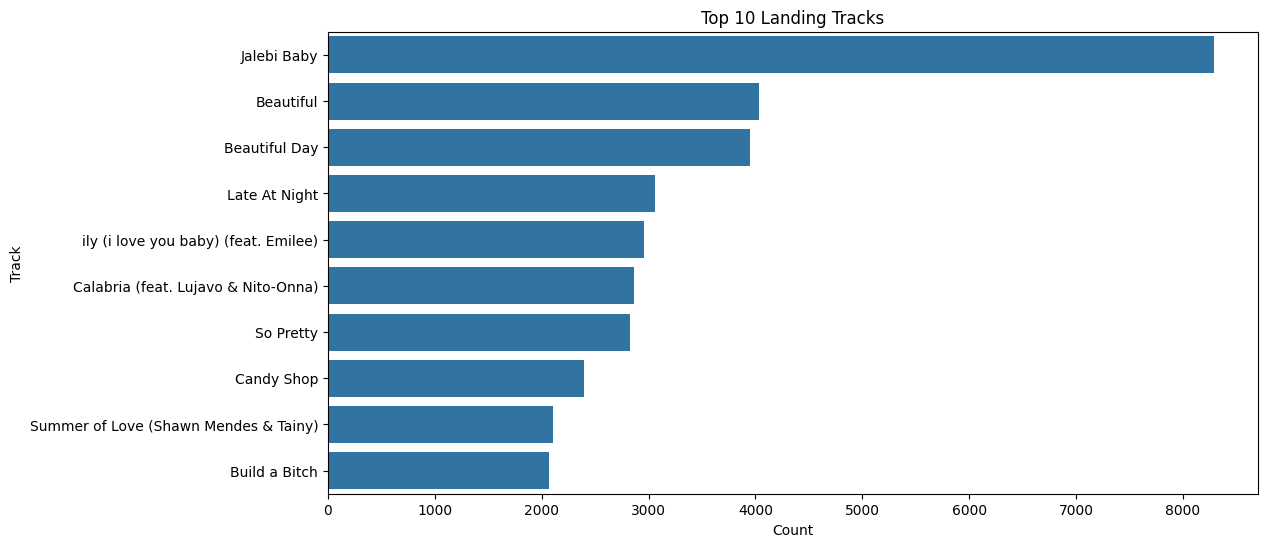

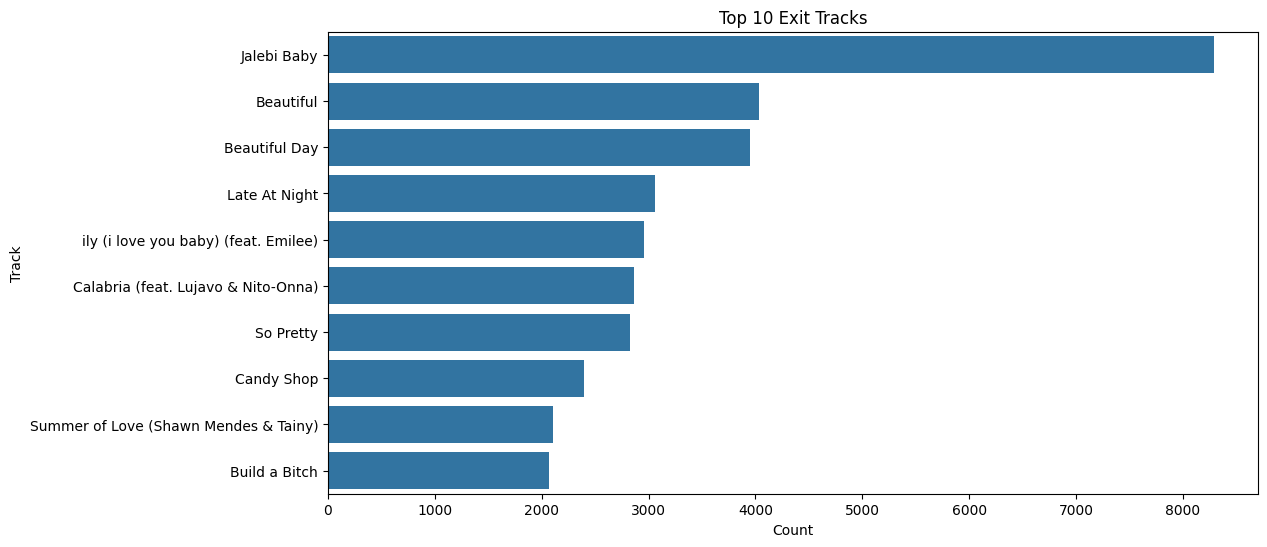

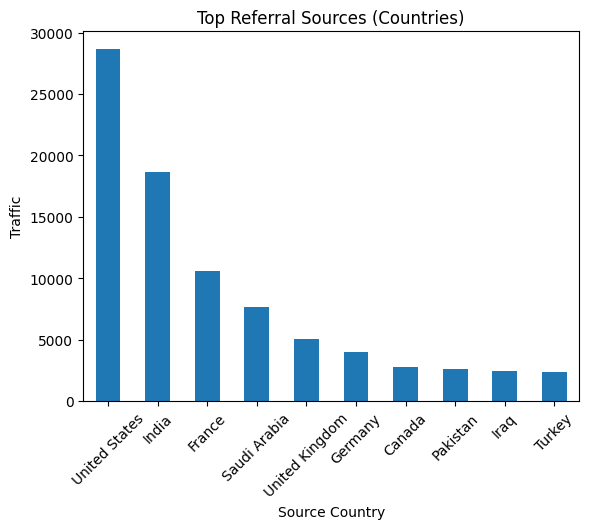

                                      track  \
984                             Jalebi Baby   
219                               Beautiful   
220                           Beautiful Day   
1048                          Late At Night   
2250   ily (i love you baby) (feat. Emilee)   
344     Calabria (feat. Lujavo & Nito-Onna)   
1760                              So Pretty   
363                              Candy Shop   
1835  Summer of Love (Shawn Mendes & Tainy)   
328                           Build a Bitch   

                                  next_page  count  
984                             Jalebi Baby   8287  
219                               Beautiful   4034  
220                           Beautiful Day   3949  
1048                          Late At Night   3058  
2250   ily (i love you baby) (feat. Emilee)   2953  
344     Calabria (feat. Lujavo & Nito-Onna)   2864  
1760                              So Pretty   2828  
363                              Candy Shop   2395  
1835 

In [19]:
#Visualization: Landing Pages
plt.figure(figsize=(12, 6))
sns.countplot(y='track', data=df, order=df['track'].value_counts().index[:10])
plt.title('Top 10 Landing Tracks')
plt.xlabel('Count')
plt.ylabel('Track')
plt.show()

#Visualization: Exit Pages
plt.figure(figsize=(12, 6))
sns.countplot(y='track', data=df, order=df['track'].value_counts().index[:10])
plt.title('Top 10 Exit Tracks')
plt.xlabel('Count')
plt.ylabel('Track')
plt.show()

#Visualization: Referral Sources
referral_counts.plot(kind='bar')
plt.title("Top Referral Sources (Countries)")
plt.xlabel("Source Country")
plt.ylabel("Traffic")
plt.xticks(rotation=45)
plt.show()

# User Flow Analysis
df['next_page'] = df.groupby(['user_id','session_id'])['track'].shift(-1)
flows = df.groupby(['track','next_page']).size().reset_index(name='count')
top_flows = flows.sort_values(by='count', ascending=False).head(10)
print(top_flows)

#Conclusion Print
print("\nConclusion:")
print("- Bounce Rate: {:.2f}%".format(bounce_rate))
print("- Average Session Duration: {:.2f} seconds".format(avg_session_duration))
print("- Top 10 Landing Pages (Tracks):")
print(top_landing_pages)
print("- Top 10 Exit Pages (Tracks):")
print(top_exit_pages)
print("- Top 10 Referral Sources (Countries):")
print(referral_counts)